# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [5]:
#Write your code here
import pandas as pd 

# 1
rainfall = pd.read_csv('rainfall.csv', header=None)
rainfall = rainfall[0].str.split(',', expand=True)
rainfall.columns = rainfall.iloc[0]
rainfall = rainfall.drop(index=0).reset_index(drop=True)


# 2
print ( "first 5 rows in the dataset" ) 
print(rainfall.head())

# 3
print (rainfall.isnull().sum())
for column in rainfall.columns:
    if rainfall[column].isnull().sum() > 0:
        if rainfall[column].dtype == 'object':
            rainfall[column].fillna(rainfall[column].mode()[0], inplace=True)
        else:
            rainfall[column].fillna(rainfall[column].mean(), inplace=True)

# 4
print("\nSummary statistics for numeric columns:")
numeric_columns = ['Rainfall_mm' , 'RainyDays' , 'MaxTemp_C', 'MinTemp_C']
for col in numeric_columns:
    rainfall[col] = pd.to_numeric(rainfall[col], errors='coerce')
rainfall.describe()


first 5 rows in the dataset
0 Region  Year Month   Station Rainfall_mm RainyDays MaxTemp_C MinTemp_C  \
0  North  2023   Jan  StationA        56.2         9      12.1       2.5   
1  North  2023   Feb  StationA        72.1        12      14.7       3.0   
2  North  2023   Jan  StationB        60.5        10      11.2       1.8   
3  South  2023   Jan  StationC        81.0        13      19.6       7.2   
4  South  2023   Feb  StationC        63.4        11      20.1       7.7   

0 UrbanRural  
0      Urban  
1      Urban  
2      Rural  
3      Urban  
4      Urban  
0
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64

Summary statistics for numeric columns:


,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
count,10.000000,10.00000,10.000000,10.000000
mean,66.160000,10.90000,16.100000,4.740000
std,12.154121,1.66333,2.982542,2.029888
min,45.700000,8.00000,11.200000,1.800000
25%,59.825000,10.00000,14.775000,3.050000
50%,62.450000,11.00000,16.100000,5.100000
75%,76.075000,12.00000,18.125000,6.050000
max,84.200000,13.00000,20.100000,7.700000


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [6]:
#Write your code here
station_summary = rainfall.groupby('Station').agg({
    'Rainfall_mm' : 'sum',
    'RainyDays' : 'mean',
    'MaxTemp_C' : 'mean',
    'MinTemp_C' : 'mean',
})

dict = {'Rainfall_mm': 'Total Rainfall','RainyDays': 'Average Rainy Days','MaxTemp_C': 'Average Max Temperature','MinTemp_C': 'Average Min Temperature'}

station_summary = station_summary.rename(columns=dict)

display(station_summary)


,Total Rainfall,Average Rainy Days,Average Max Temperature,Average Min Temperature
Station,,,,
StationA,128.3,10.5,13.40,2.75
StationB,122.0,10.5,13.10,2.50
StationC,144.4,12.0,19.85,7.45
StationD,105.3,9.0,16.65,5.90
StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [7]:
#Write your code here
Region_UrbanRural = rainfall.groupby(['Region','UrbanRural']).agg({
    'Rainfall_mm' : 'mean',
    'RainyDays' : 'mean',
    'MaxTemp_C' : 'mean',
})

Region_UrbanRural = Region_UrbanRural.rename( columns = dict )
display(Region_UrbanRural)


0                  Total Rainfall  Average Rainy Days  Average Max Temperature
Region UrbanRural                                                             
East   Rural                52.65                 9.0                    16.65
North  Rural                61.00                10.5                    13.10
       Urban                64.15                10.5                    13.40
South  Urban                72.20                12.0                    19.85
West   Urban                80.80                12.5                    17.50

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [8]:
#Write your code here
Month_Region = rainfall.groupby(['Month','Region']).agg({
    'Rainfall_mm' : ['sum','mean','max','min'],
    })

display(Month_Region)


0            Rainfall_mm                   
                     sum   mean   max   min
Month Region                               
Feb   East          59.6  59.60  59.6  59.6
      North         72.1  72.10  72.1  72.1
      South         63.4  63.40  63.4  63.4
      West          84.2  84.20  84.2  84.2
Jan   East          45.7  45.70  45.7  45.7
      North        116.7  58.35  60.5  56.2
      South         81.0  81.00  81.0  81.0
      West          77.4  77.40  77.4  77.4
Mar   North         61.5  61.50  61.5  61.5

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [9]:
#Write your code here
max_index = Month_Region[('Rainfall_mm', 'max')].idxmax()
max_value = Month_Region[('Rainfall_mm', 'max')].max()

month, region = max_index
print(f"🌧️ The highest recorded single rainfall was {max_value} mm in {region} during {month}.")




🌧️ The highest recorded single rainfall was 84.2 mm in West during Feb.


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [10]:
#Write your code here
Year_UrbanRural = rainfall.groupby(['Year','UrbanRural']).agg({
    'Rainfall_mm' : ['mean','min','max']
})

display ( Year_UrbanRural )

0               Rainfall_mm            
                       mean   min   max
Year UrbanRural                        
2023 Rural        56.825000  45.7  61.5
     Urban        72.383333  56.2  84.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [11]:
#Write your code here
rainfall['TempRange'] = rainfall['MaxTemp_C'] - rainfall['MinTemp_C']

temp_range_summary = rainfall.groupby(['Region', 'Month'])['TempRange'].mean().reset_index()

temp_range_summary = temp_range_summary.rename(columns={'TempRange': 'Avg_Temp_Range'})

display(temp_range_summary)

,Region,Month,Avg_Temp_Range
0,East,Feb,11.7
1,East,Jan,9.8
2,North,Feb,11.7
3,North,Jan,9.5
4,North,Mar,11.8
5,South,Feb,12.4
6,South,Jan,12.4
7,West,Feb,12.9
8,West,Jan,11.9


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



UrbanRural,Rural,Urban
Region,,
East,105.3,NaN
North,122.0,128.3
South,NaN,144.4
West,NaN,161.6


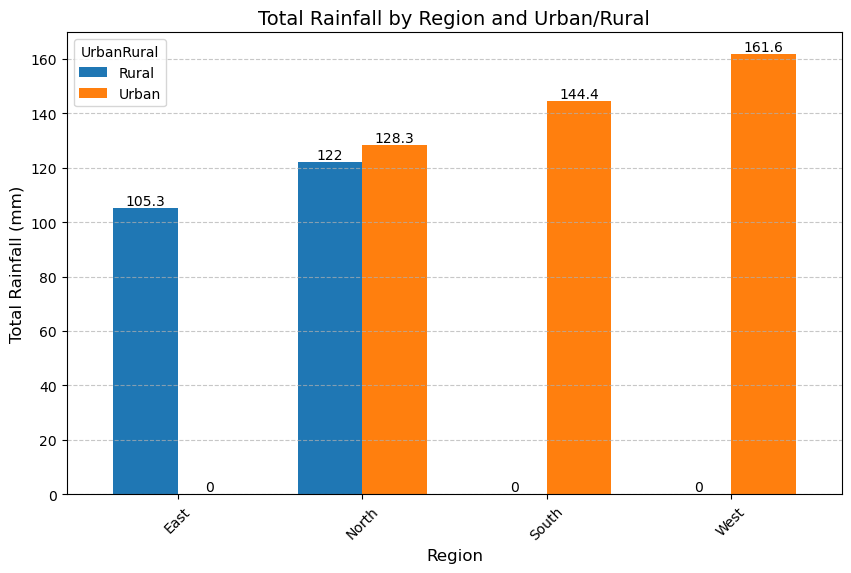

In [38]:
import matplotlib.pyplot as plt

RU = rainfall.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack()
display(RU)

ax = RU.plot.bar(figsize=(10, 6), width=0.7)
ax.set_title('Total Rainfall by Region and Urban/Rural', fontsize=14)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Rainfall (mm)', fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.show()


2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



In [ ]:
#Write your code here


3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



In [ ]:
#Write your code here


4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



In [14]:
#Write your code here


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



In [15]:
#Write your code here


6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



In [16]:
#Write your code here


7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [18]:
#Write your code here


## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


In [22]:
#Write your code here



2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


In [20]:
#Write your code here



3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here






